# The Basics of Portfolio Choice

This notebook analyses the effect of leverage and diversification on the portfolio performance.

## Load Packages and Extra Functions

In [1]:
using Printf

include("src/printmat.jl");

In [2]:
using Plots
default(size = (480,320),fmt = :png)   #or :svg

# Portfolio Return: Expected Value and Variance

We form a portfolio by combining $n$ assets: $v$ is the vector of $n$ portfolio weights. The portfolio return is

$R_v = v'R,$

where $R$ is a vector of returns of the $n$ assets.

In [3]:
v = [0.8,0.2]
printblue("Portfolio weights:")
printmat(v;rowNames=["asset 1","asset 2"])

Portfolio weights:
asset 1     0.800
asset 2     0.200



The expected portfolio return and the portfolio variance can be computed as

$\text{E}R_v = v'\mu$ and

$\text{Var}(R_v) = v'\Sigma v,$

where $\mu$ is a vector of expected expected (average) returns of the $n$ assets and $\Sigma$ the $n \times n$ variance-covariance matrix.

In [4]:
μ = [9,6]/100                    #\mu[TAB] to get μ
Σ = [256 96;                     #\Sigma[TAB]
     96 144]/100^2

printblue("expected returns*100: ")
printmat(μ*100;rowNames=["asset 1","asset 2"],prec=2)

printblue("covariance matrix*100^2:")
printmat(Σ*100^2;rowNames=["asset 1","asset 2"],colNames=["asset 1","asset 2"],prec=2)

expected returns*100: 
asset 1      9.00
asset 2      6.00

covariance matrix*100^2:
          asset 1   asset 2
asset 1    256.00     96.00
asset 2     96.00    144.00



In [5]:
ERᵥ   = v'μ
VarRᵥ = v'Σ*v

printlnPs("Expected portfolio return: ",ERᵥ)
printlnPs("Portfolio variance and std:",VarRᵥ,sqrt(VarRᵥ))

Expected portfolio return:      0.084
Portfolio variance and std:     0.020     0.142


# Leverage: A Risky and a Riskfree Asset

Suppose you can invest in a risky asset (with return $R$, expected return $\mu$ and standard deviation $\sigma$) and also in a riskfree asset (at the rate $R_f$). 

With the portfolio weight $v$ on the risky asset, the portfolio return is

$R_p = v R + (1-v)R_f$.

$v>1$ is called leverage (and it is financed by borrowing at the rate $R_f$).

The average and standard deviation of the portfolio are

$\text{E}R_p = v \mu + (1-v)R_f$ 

and 

$\text{Std}(R_p) = |v|\sigma$,

where $(\mu,\sigma)$ are the average return and standard deviation of the risky asset.

By considering different values of $v$, we can show what sort of combinations of $\text{E}R_p$ and $\text{Std}(R_p)$ that can be achieved.

### A Remark on the Code

1. if `v=0.2`, then `println("hello is $v")` will print `hello is 0.2`
2. if `v_range=[0.5,0.25]`, then `1.0 .- v_range` will give `[1-0.5,1-0.25]`.

In [6]:
μ  = 9.5/100  #expected return of the risky asset
σ  = 8/100    #std of the risky asset
Rf = 3/100    #risk free return (interest rate)

v  = 0.5      #try a single value of v

ERₚ   = v*μ + (1 - v)*Rf
StdRₚ = abs(v)*σ

printlnPs("ERₚ and Std(Rₚ) when v=$v:",ERₚ,StdRₚ)

ERₚ and Std(Rₚ) when v=0.5:     0.062     0.040


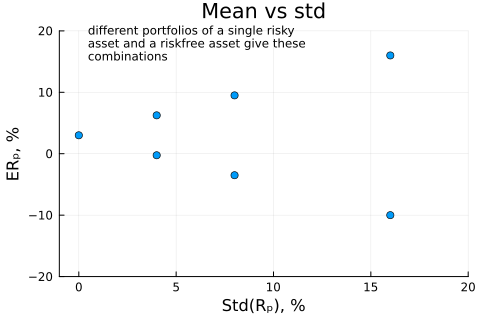

In [7]:
v_range = [-2,-1,-0.5,0,0.5,1,2]           #try different values of v
ERₚ     = v_range*μ + (1 .- v_range)*Rf    #a vector of the same length as v_range, notice the .-
StdRₚ   = abs.(v_range)*σ                  #notice the dot.

txt = text("different portfolios of a single risky\nasset and a riskfree asset give these\ncombinations",8,:left)

p1 = scatter( StdRₚ*100,ERₚ*100,
              legend = false,
              ylim = (-20,20),
              xlim = (-1,20),
              title = "Mean vs std",
              xlabel = "Std(Rₚ), %",
              ylabel = "ERₚ, %",
              annotation = (0.5,18,txt) )
display(p1)

#    Diversification

## The Correlations

The variance of an *equally weighted* portfolio of *two assets* is

$\text{Var}(R_p) = \sigma_{11}/4 + \sigma_{22}/4 + \sigma_{12}/2,$

where $\sigma_{ii}$ the variance of asset $i$ and $\sigma_{ij}$ is the covariance of assets $i$ and $j$. 
Notice that $\sigma_{12} = \rho\sqrt{\sigma_{11}\sigma_{22}}$, where $\rho$ is the correlation.

We here use $\sigma_{ii}$ to denote a variance since it is tricky to write $\sigma_i^2$ in the code (it looks ugly, like `σ²₁`).

In [8]:
σ₁₁ = 256/100^2
σ₂₂ = σ₁₁             #assume the same variance of the two assets
ρ   = 0.5

VarRₚ = σ₁₁/4 + σ₂₂/4 + ρ*sqrt(σ₁₁*σ₂₂)/2

println("With a corrrelation of $ρ, we get")
printmat([σ₁₁;VarRₚ];rowNames=["Individual variance","portfolio variance"])

With a corrrelation of 0.5, we get
Individual variance     0.026
portfolio variance      0.019



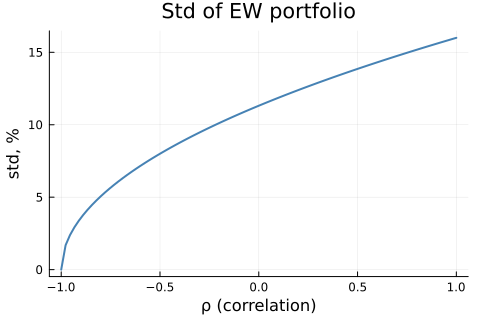

In [9]:
L = 91
ρ_range = range(-1,1,length=L)    #repeat calculations for different correlations

VarRₚ = fill(NaN,L)
for i in 1:L
  VarRₚ[i] = σ₁₁/4 + σ₂₂/4 + ρ_range[i]*sqrt(σ₁₁*σ₂₂)/2
end

p1 = plot( ρ_range,100*sqrt.(VarRₚ),
           linecolor = :steelblue,
           linewidth = 2,
           ylabel = "std, %",
           title = "Std of EW portfolio",
           xlabel = "ρ (correlation)",
           label = false)
display(p1)

## The Number of Assets

More generally, the variance of an equally weighted portfolio of *n assets* is

$\text{Var}(R_p) = (\bar{\sigma}_{ii} - \bar{\sigma}_{ij})/n + \bar{\sigma}_{ij}$,

where $\bar{\sigma}_{ii}$ is the average variance (across the assets) and $\bar{\sigma}_{ij}$ is the average covariance. (In the code, we use `σᵢᵢ_avg` to denote this.)

In [10]:
σᵢᵢ_avg = σ₁₁                       #average variance, for simplicity same as σ₁₁
σᵢⱼ_avg = ρ*sqrt(σᵢᵢ_avg*σᵢᵢ_avg)   #average covariance
n_range = 1:49                      #try all these values of n

VarRₚ = (σᵢᵢ_avg-σᵢⱼ_avg)./n_range .+ σᵢⱼ_avg     #variance of equally weighted portfolio

printblue("Portfolio variance and std, n = 1 to 3")
printmat([VarRₚ[1:3] sqrt.(VarRₚ[1:3])];colNames=["var","std"],rowNames=1:3,cell00="n")

Portfolio variance and std, n = 1 to 3
n       var       std
1     0.026     0.160
2     0.019     0.139
3     0.017     0.131



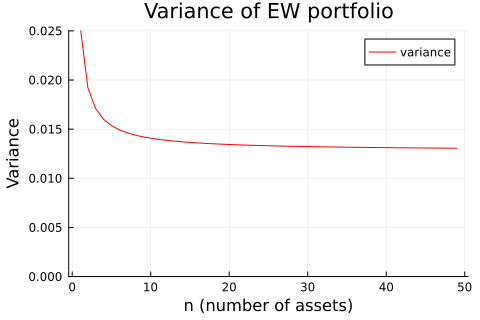

In [11]:
p1 = plot( n_range,VarRₚ,
           linecolor = :red,
           linewidth = 1,
           ylim = (0,0.025),
           label = "variance",
           title = "Variance of EW portfolio",
           xlabel = "n (number of assets)",
           ylabel = "Variance" )
display(p1)

# Calculate the Average Correlation (extra)

#### A Remark of the Code
`tril(C,-1)` creates a new matrix where all $n(n-1)/2$ elements below the main diagonal are kept unchanged, and all other elements are replaced by zeros.

In [12]:
using LinearAlgebra

C = [1     0.50  0.25;         #a correlation matrix
     0.50  1     0.10;
     0.25  0.10  1   ]

n = size(C,1)
c_avg = sum(tril(C,-1))/(n*(n-1)/2)    #average of the n(n-1)/2
printlnPs(c_avg)                       #numbers below the main diagonal

     0.283
